### From the sunpy example 
https://docs.sunpy.org/en/stable/generated/gallery/plotting/solar_cycle_example.html

In [3]:
#Imports
import matplotlib.pyplot as plt

import astropy.units as u
from astropy.time import Time, TimeDelta
from astropy.visualization import time_support

import sunpy.timeseries as ts
from sunpy.net import Fido
from sunpy.net import attrs as a
from sunpy.time import TimeRange

import numpy as np

/home/rahyndman/miniforge3/envs/sunpyVenv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# get data
time_range = TimeRange("1994-01-01 00:00", Time.now()) # I've used the start of the year before the C23 minimum that Tindale and Chapman (2017) use
result = Fido.search(a.Time(time_range), a.Instrument('noaa-indices')) # fido search for the noaa indices in the time range
f_noaa_indices = Fido.fetch(result)
result = Fido.search(a.Time(time_range.end, time_range.end + TimeDelta(4 * u.year)),
                     a.Instrument('noaa-predict')) # get the predicted sunspot numbers from NOAA (4 years in future)
f_noaa_predict = Fido.fetch(result)

Files Downloaded: 100%|██████████| 1/1 [00:00<00:00,  2.04file/s]
/home/rahyndman/miniforge3/envs/sunpyVenv/lib/python3.14/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/rahyndman/miniforge3/envs/sunpyVenv/lib/python3.14/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
Files Downloaded: 100%|██████████| 1/1 [00:00<00:00,  1.18file/s]


In [5]:
#loading data into TimeSeries objects
noaa = ts.TimeSeries(f_noaa_indices, source='noaaindices').truncate(time_range) 
noaa_predict = ts.TimeSeries(f_noaa_predict, source='noaapredictindices')

/home/rahyndman/miniforge3/envs/sunpyVenv/lib/python3.14/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/rahyndman/miniforge3/envs/sunpyVenv/lib/python3.14/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
2026-08-14 15:12:19 - sunpy - WARNING: SunpyUserWarning: Unknown units for high25_ssn
2026-08-14 15:12:19 - sunpy - WARNING: SunpyUserWarning: Unknown units for high75_ssn
2026-08-14 15:12:19 - sunpy - WARNING: SunpyUserWarning: Unknown units for low25_ssn
2026-08-14 15:12:19 - sunpy - WARNING: SunpyUserWarning: Unknown units for low75_ssn
2026-08-14 15:12:19 - sunpy - WARNING: SunpyUserWarning: Unknown units for high25_f10.7
2026-08-14 15:12:19 - sunpy - WARNING: SunpyUserWarning: Unknown units for high75_f10.7
2026-08-14 15:12:19 - sunp

In [6]:
TitleSize = 25
AxisSize = 20
TickSize = 15

/home/rahyndman/miniforge3/envs/sunpyVenv/lib/python3.14/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


<bound method GenericTimeSeries.quantity of <sunpy.timeseries.sources.noaa.NOAAIndicesTimeSeries object at 0x7046783c2d70>
SunPy TimeSeries
----------------
Observatory:			Unknown
Instrument:			<a href=https://www.swpc.noaa.gov/products/solar-cycle-progression target="_blank">Unknown</a>
Channel(s):			sunspot RI<br>sunspot RI smooth<br>sunspot SWO<br>sunspot SWO smooth<br>radio flux<br>radio flux smooth
Start Date:			1996-05-01 00:00:00
End Date:			1996-05-01 00:00:00
Center Date:			1996-05-01 00:00:00
Resolution:			0.0 s
Samples per Channel:		1
Data Range(s):		sunspot RI           0.00E+00<br>sunspot RI smooth    0.00E+00<br>sunspot SWO               NaN<br>sunspot SWO smooth        NaN<br>radio flux                NaN<br>radio flux smooth         NaN
Units:			dimensionless<br>W / (Hz m2)
            sunspot RI  sunspot RI smooth  sunspot SWO  sunspot SWO smooth  \
1996-05-01         7.6               11.2          NaN                 NaN   

            radio flux  radio flux smooth 

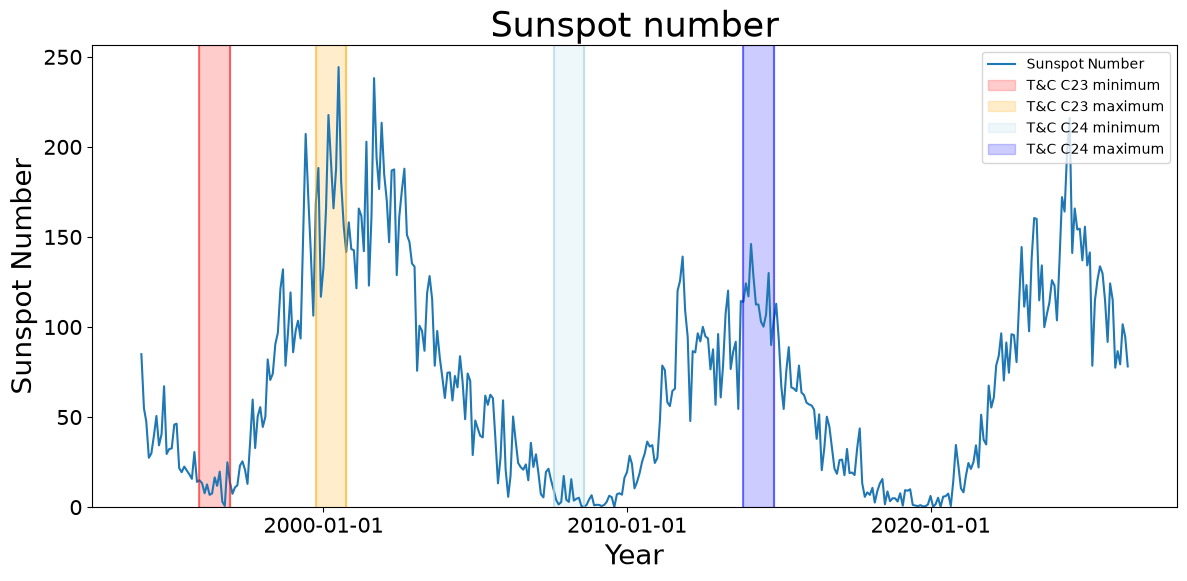

In [7]:
time_support()
fig, ax = plt.subplots(figsize=(14,6))
ax.plot(noaa.time, noaa.quantity('sunspot RI'), label='Sunspot Number')
# ax.plot(
#     noaa_predict.time, noaa_predict.quantity('sunspot'),
#     color='grey', label='Near-term Prediction'
# )
# ax.fill_between(
#     noaa_predict.time, noaa_predict.quantity('sunspot low'),
#     noaa_predict.quantity('sunspot high'), alpha=0.3, color='grey'
# )
ax.set_ylim(bottom=0)
ax.set_ylabel('Sunspot Number', fontsize=AxisSize)
ax.set_xlabel('Year', fontsize=AxisSize)

# times = []
# for t in range(10):
#     times.append(Time('1994-01-01').jd1-2400000 + 4*t*( (Time('1996-01-01').jd1-2400000) - (Time('1995-01-01').jd1-2400000) ) )
# plt.xticks(times, fontsize=TickSize)

plt.xticks(fontsize=TickSize)
plt.yticks(fontsize=TickSize)
plt.title("Sunspot number", fontsize=TitleSize)

# print(noaa.time[0])

#Tindale and Chapman - "These dates were chosen based on the sunspot number, as in Hush et al. (2015)."

#C23 - Min
ax.axvline(Time('1995-12-01').jd1-2400000, color='red', alpha = 0.5)
ax.axvline(Time('1996-11-30').jd1-2400000, color='red', alpha = 0.5)
ax.axvspan(Time('1995-12-01').jd1-2400000, Time('1996-11-30').jd1-2400000, color='red', alpha=0.2, label = "T&C C23 minimum")
C23MinMidtimerange = TimeRange("1996-05-01", "1996-05-31") # I've used the start of the year before the C23 minimum that Tindale and Chapman (2017) use
C23MinMid = ts.TimeSeries(f_noaa_indices, source='noaaindices').truncate(C23MinMidtimerange)
# C23Mintime_range = TimeRange("1995-12-01", "1996-11-30") # I've used the start of the year before the C23 minimum that Tindale and Chapman (2017) use
# C23Minimum = ts.TimeSeries(f_noaa_indices, source='noaaindices').truncate(C23Mintime_range)
print(C23MinMid.quantity) 
# ax.axvline(Time('1996-05-01').jd1-2400000, color='red')

#C23 - Max
ax.axvline(Time('1999-10-01').jd1-2400000, color='orange', alpha = 0.5)
ax.axvline(Time('2000-09-30').jd1-2400000, color='orange', alpha = 0.5)
ax.axvspan(Time('1999-10-01').jd1-2400000, Time('2000-09-30').jd1-2400000, color='orange', alpha=0.2, label = "T&C C23 maximum")

# C24 - Min
ax.axvline(Time('2007-08-01').jd1-2400000, color='lightblue', alpha = 0.7)
ax.axvline(Time('2008-07-31').jd1-2400000, color='lightblue', alpha = 0.7)
ax.axvspan(Time('2007-08-01').jd1-2400000, Time('2008-07-31').jd1-2400000, color='lightblue', alpha=0.2, label = "T&C C24 minimum")

#C24 - Max
ax.axvline(Time('2013-11-01').jd1-2400000, color='blue', alpha = 0.5)
ax.axvline(Time('2014-10-31').jd1-2400000, color='blue', alpha = 0.5)
ax.axvspan(Time('2013-11-01').jd1-2400000, Time('2014-10-31').jd1-2400000, color='blue', alpha=0.2, label = "T&C C24 maximum")

ax.legend()
plt.show()

# Yearly

/home/rahyndman/miniforge3/envs/sunpyVenv/lib/python3.14/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


<bound method GenericTimeSeries.quantity of <sunpy.timeseries.sources.noaa.NOAAIndicesTimeSeries object at 0x704674211970>
SunPy TimeSeries
----------------
Observatory:			Unknown
Instrument:			<a href=https://www.swpc.noaa.gov/products/solar-cycle-progression target="_blank">Unknown</a>
Channel(s):			sunspot RI<br>sunspot RI smooth<br>sunspot SWO<br>sunspot SWO smooth<br>radio flux<br>radio flux smooth
Start Date:			1996-05-01 00:00:00
End Date:			1996-05-01 00:00:00
Center Date:			1996-05-01 00:00:00
Resolution:			0.0 s
Samples per Channel:		1
Data Range(s):		sunspot RI           0.00E+00<br>sunspot RI smooth    0.00E+00<br>sunspot SWO               NaN<br>sunspot SWO smooth        NaN<br>radio flux                NaN<br>radio flux smooth         NaN
Units:			dimensionless<br>W / (Hz m2)
            sunspot RI  sunspot RI smooth  sunspot SWO  sunspot SWO smooth  \
1996-05-01         7.6               11.2          NaN                 NaN   

            radio flux  radio flux smooth 

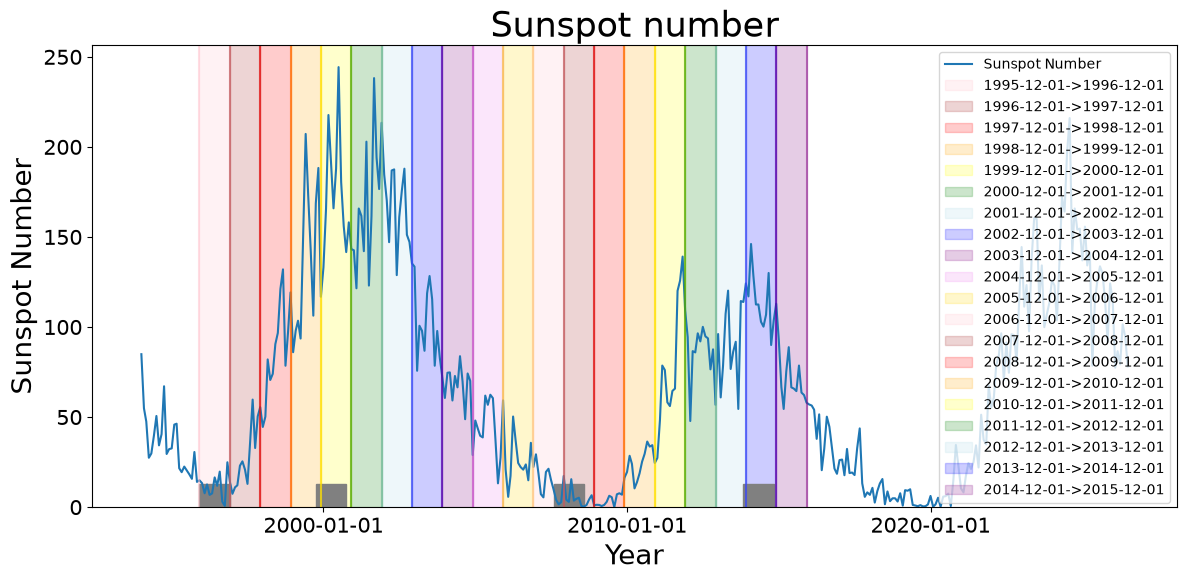

In [64]:
time_support()
fig, ax = plt.subplots(figsize=(14,6))
ax.plot(noaa.time, noaa.quantity('sunspot RI'), label='Sunspot Number')
# ax.plot(
#     noaa_predict.time, noaa_predict.quantity('sunspot'),
#     color='grey', label='Near-term Prediction'
# )
# ax.fill_between(
#     noaa_predict.time, noaa_predict.quantity('sunspot low'),
#     noaa_predict.quantity('sunspot high'), alpha=0.3, color='grey'
# )
ax.set_ylim(bottom=0)
ax.set_ylabel('Sunspot Number', fontsize=AxisSize)
ax.set_xlabel('Year', fontsize=AxisSize)

# times = []
# for t in range(10):
#     times.append(Time('1994-01-01').jd1-2400000 + 4*t*( (Time('1996-01-01').jd1-2400000) - (Time('1995-01-01').jd1-2400000) ) )
# plt.xticks(times, fontsize=TickSize)

plt.xticks(fontsize=TickSize)
plt.yticks(fontsize=TickSize)
plt.title("Sunspot number", fontsize=TitleSize)

# print(noaa.time[0])

#Tindale and Chapman - "These dates were chosen based on the sunspot number, as in Hush et al. (2015)."

DateStrings = [ ['1995-12-01', '1996-12-01'],
              ['1996-12-01', '1997-12-01'],
              ['1997-12-01', '1998-12-01'],
              ['1998-12-01', '1999-12-01'],
              ['1999-12-01', '2000-12-01'],
              ['2000-12-01', '2001-12-01'],
              ['2001-12-01', '2002-12-01'],
              ['2002-12-01', '2003-12-01'],
              ['2003-12-01', '2004-12-01'],
              ['2004-12-01', '2005-12-01'],
              ['2005-12-01', '2006-12-01'],
              ['2006-12-01', '2007-12-01'],
              ['2007-12-01', '2008-12-01'],
              ['2008-12-01', '2009-12-01'],
              ['2009-12-01', '2010-12-01'],
              ['2010-12-01', '2011-12-01'],
              ['2011-12-01', '2012-12-01'],
              ['2012-12-01', '2013-12-01'],
              ['2013-12-01', '2014-12-01'],
              ['2014-12-01', '2015-12-01'] ]
            #   '2007-12-01' '2008-12-01'
            #   '2008-12-01' '2009-12-01'
            #   '2009-12-01' '2010-12-01'
            #   '2010-12-01' '2011-12-01'

dateRanges = []
for i in range(len(DateStrings)):
    dateRanges.append([Time(DateStrings[i][0]).jd1-2400000, Time(DateStrings[i][1]).jd1-2400000])

# dateRanges = [ [Time('1995-12-01').jd1-2400000, Time('1996-12-01').jd1-2400000],
#               [Time('1996-12-01').jd1-2400000, Time('1997-12-01').jd1-2400000],
#               [Time('1997-12-01').jd1-2400000, Time('1998-12-01').jd1-2400000],
#               [Time('1998-12-01').jd1-2400000, Time('1999-12-01').jd1-2400000],
#               [Time('1999-12-01').jd1-2400000, Time('2000-12-01').jd1-2400000],
#               [Time('2000-12-01').jd1-2400000, Time('2001-12-01').jd1-2400000],
#               [Time('2001-12-01').jd1-2400000, Time('2002-12-01').jd1-2400000],
#               [Time('2002-12-01').jd1-2400000, Time('2003-12-01').jd1-2400000],
#               [Time('2003-12-01').jd1-2400000, Time('2004-12-01').jd1-2400000],
#               [Time('2004-12-01').jd1-2400000, Time('2005-12-01').jd1-2400000],
#               [Time('2005-12-01').jd1-2400000, Time('2006-12-01').jd1-2400000],
#               [Time('2006-12-01').jd1-2400000, Time('2007-12-01').jd1-2400000],
#               [Time('2007-12-01').jd1-2400000, Time('2008-12-01').jd1-2400000],
#               [Time('2008-12-01').jd1-2400000, Time('2009-12-01').jd1-2400000],
#               [Time('2009-12-01').jd1-2400000, Time('2010-12-01').jd1-2400000],
#               [Time('2010-12-01').jd1-2400000, Time('2011-12-01').jd1-2400000],
#               [Time('2011-12-01').jd1-2400000, Time('2012-12-01').jd1-2400000],
#               [Time('2012-12-01').jd1-2400000, Time('2013-12-01').jd1-2400000],
#               [Time('2013-12-01').jd1-2400000, Time('2014-12-01').jd1-2400000],
#               [Time('2014-12-01').jd1-2400000, Time('2015-12-01').jd1-2400000]
#             #   [Time('2007-12-01').jd1-2400000, Time('2008-12-01').jd1-2400000],
#             #   [Time('2008-12-01').jd1-2400000, Time('2009-12-01').jd1-2400000],
#             #   [Time('2009-12-01').jd1-2400000, Time('2010-12-01').jd1-2400000],
#             #   [Time('2010-12-01').jd1-2400000, Time('2011-12-01').jd1-2400000]
#               ]

Colour = ['pink','brown', 'red', 'orange', 'yellow', 'green', 'lightblue', 'blue', 'purple', 'violet','gold', 'pink','brown', 'red', 'orange', 'yellow', 'green', 'lightblue', 'blue', 'purple', 'violet', 'gold', 'pink']

for i in range(len(dateRanges)):
    ax.axvline(dateRanges[i][0], color=Colour[i], alpha = 0.5)
    ax.axvspan(dateRanges[i][0], dateRanges[i][1], color=Colour[i], alpha=0.2, label = DateStrings[i][0] + "->" + DateStrings[i][1])
    ax.axvline(dateRanges[i][1], color=Colour[i], alpha = 0.5)

TandCAlpha = 1
TandCAlpha2 = 0.7
TandCPosition1 = 0
TandCPosition2 = 0.05

#Tindale and Chapman - "These dates were chosen based on the sunspot number, as in Hush et al. (2015)."
ax.axvspan(Time('1995-12-01').jd1-2400000, Time('1996-11-30').jd1-2400000, TandCPosition1, TandCPosition2, color='grey', alpha=TandCAlpha)#, label = "T&C C23 minimum")
ax.axvspan(Time('1999-10-01').jd1-2400000, Time('2000-09-30').jd1-2400000, TandCPosition1, TandCPosition2, color='grey', alpha=TandCAlpha)#, label = "T&C C23 maximum")
ax.axvspan(Time('2007-08-01').jd1-2400000, Time('2008-07-31').jd1-2400000, TandCPosition1, TandCPosition2, color='grey', alpha=TandCAlpha)#, label = "T&C C24 minimum")
ax.axvspan(Time('2013-11-01').jd1-2400000, Time('2014-10-31').jd1-2400000, TandCPosition1, TandCPosition2, color='grey', alpha=TandCAlpha)#, label = "T&C C24 maximum")

# ax.axvline(Time('1995-12-01').jd1-2400000, TandCPosition1, TandCPosition2, color='black', alpha=TandCAlpha2, label = "T&C C23 minimum")
# ax.axvline(Time('1999-10-01').jd1-2400000, TandCPosition1, TandCPosition2, color='black', alpha=TandCAlpha2, label = "T&C C23 maximum")
# ax.axvline(Time('2007-08-01').jd1-2400000, TandCPosition1, TandCPosition2, color='black', alpha=TandCAlpha2, label = "T&C C24 minimum")
# ax.axvline(Time('2013-11-01').jd1-2400000, TandCPosition1, TandCPosition2, color='black', alpha=TandCAlpha2, label = "T&C C24 maximum")

# ax.axvline(Time('1996-11-30').jd1-2400000, TandCPosition1, TandCPosition2, color='black', alpha=TandCAlpha2, label = "T&C C23 minimum")
# ax.axvline(Time('2000-09-30').jd1-2400000, TandCPosition1, TandCPosition2, color='black', alpha=TandCAlpha2, label = "T&C C23 maximum")
# ax.axvline(Time('2008-07-31').jd1-2400000, TandCPosition1, TandCPosition2, color='black', alpha=TandCAlpha2, label = "T&C C24 minimum")
# ax.axvline(Time('2014-10-31').jd1-2400000, TandCPosition1, TandCPosition2, color='black', alpha=TandCAlpha2, label = "T&C C24 maximum")



# axesRange = np.max(dateRanges) - np.min(dateRanges)
# print(dateRanges)
# print(axesRange)
# print( ((Time('1995-12-01').jd1-2400000) - np.min(dateRanges)) /axesRange)
# ax.hlines(150, Time('1995-12-01').jd1-2400000, Time('1996-11-30').jd1-2400000, color='grey', linestyle = '--', alpha=0.2, label = "T&C C23 minimum")
# # ax.axvspan(Time('1999-10-01').jd1-2400000, Time('2000-09-30').jd1-2400000, color='grey', alpha=0.2, label = "T&C C23 maximum")
# # ax.axvspan(Time('2007-08-01').jd1-2400000, Time('2008-07-31').jd1-2400000, color='grey', alpha=0.2, label = "T&C C24 minimum")
# # ax.axvspan(Time('2013-11-01').jd1-2400000, Time('2014-10-31').jd1-2400000, color='grey', alpha=0.2, label = "T&C C24 maximum")
# ax.axhline(y=.5, xmin = (Time('1995-12-01').jd1-2400000)/axesRange, xmax = (Time('1996-11-30').jd1-2400000)/axesRange, linewidth = 10)
# # ax.axhline(y=.5, xmin=0.25, xmax=0.75, linewidth=10)
# #C23 - Min
# ax.axvline(Time('1996-11-30').jd1-2400000, color='red', alpha = 0.5)
# ax.axvspan(Time('1995-12-01').jd1-2400000, Time('1996-11-30').jd1-2400000, color='red', alpha=0.2, label = "T&C C23 minimum")

# C23MinMidtimerange = TimeRange("1996-05-01", "1996-05-31") # I've used the start of the year before the C23 minimum that Tindale and Chapman (2017) use
# ax.axvline(Time('1995-12-01').jd1-2400000, Time('1996-11-30').jd1-2400000, color='black', linestyle = "--", alpha=0.2, label = "T&C C23 minimum")

C23MinMidtimerange = TimeRange("1996-05-01", "1996-05-31") # I've used the start of the year before the C23 minimum that Tindale and Chapman (2017) use
C23MinMid = ts.TimeSeries(f_noaa_indices, source='noaaindices').truncate(C23MinMidtimerange)
# C23Mintime_range = TimeRange("1995-12-01", "1996-11-30") # I've used the start of the year before the C23 minimum that Tindale and Chapman (2017) use
# C23Minimum = ts.TimeSeries(f_noaa_indices, source='noaaindices').truncate(C23Mintime_range)
print(C23MinMid.quantity) 
# ax.axvline(Time('1996-05-01').jd1-2400000, color='red')

#C23 - Max
# ax.axvline(Time('1999-10-01').jd1-2400000, color='orange', alpha = 0.5)
# ax.axvline(Time('2000-09-30').jd1-2400000, color='orange', alpha = 0.5)
# ax.axvspan(Time('1999-10-01').jd1-2400000, Time('2000-09-30').jd1-2400000, color='orange', alpha=0.2, label = "T&C C23 maximum")

# # C24 - Min
# ax.axvline(Time('2007-08-01').jd1-2400000, color='lightblue', alpha = 0.7)
# ax.axvline(Time('2008-07-31').jd1-2400000, color='lightblue', alpha = 0.7)
# ax.axvspan(Time('2007-08-01').jd1-2400000, Time('2008-07-31').jd1-2400000, color='lightblue', alpha=0.2, label = "T&C C24 minimum")

# #C24 - Max
# ax.axvline(Time('2013-11-01').jd1-2400000, color='blue', alpha = 0.5)
# ax.axvline(Time('2014-10-31').jd1-2400000, color='blue', alpha = 0.5)
# ax.axvspan(Time('2013-11-01').jd1-2400000, Time('2014-10-31').jd1-2400000, color='blue', alpha=0.2, label = "T&C C24 maximum")

ax.legend()
plt.show()